# Brain Tumor Classification with ResNet50 (Fine-Tuning)

Dataset: [Brain Tumor MRI Dataset](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)

This notebook follows the same pipeline structure as the VGG16/EfficientNetB0 versions, but swaps in **ResNet50** as the backbone and uses the same **two-phase transfer learning + fine-tuning** strategy (feature extraction first, then fine-tuning the top layers with a low learning rate).

> Note: ResNet18 is not available in `tensorflow.keras.applications` — only ResNet50/101/152 (and their V2 variants) ship with Keras. ResNet50 is used here as the standard, smallest Keras-native ResNet.

In [2]:
import os
import numpy as np
import random
import json
from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, BatchNormalization, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import shuffle
import matplotlib.pyplot as plt


In [3]:
train_dir = r"Dataset\Training"
test_dir  = r"Dataset\Testing"

# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load and shuffle the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

test_paths, test_labels = shuffle(test_paths, test_labels)


In [4]:
# Define CLASS_LABELS ONCE using sorted() so order is always consistent
CLASS_LABELS = sorted(os.listdir(train_dir))
print("Class label order (fixed):", CLASS_LABELS)
print(f"Number of classes: {len(CLASS_LABELS)}")


Class label order (fixed): ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4


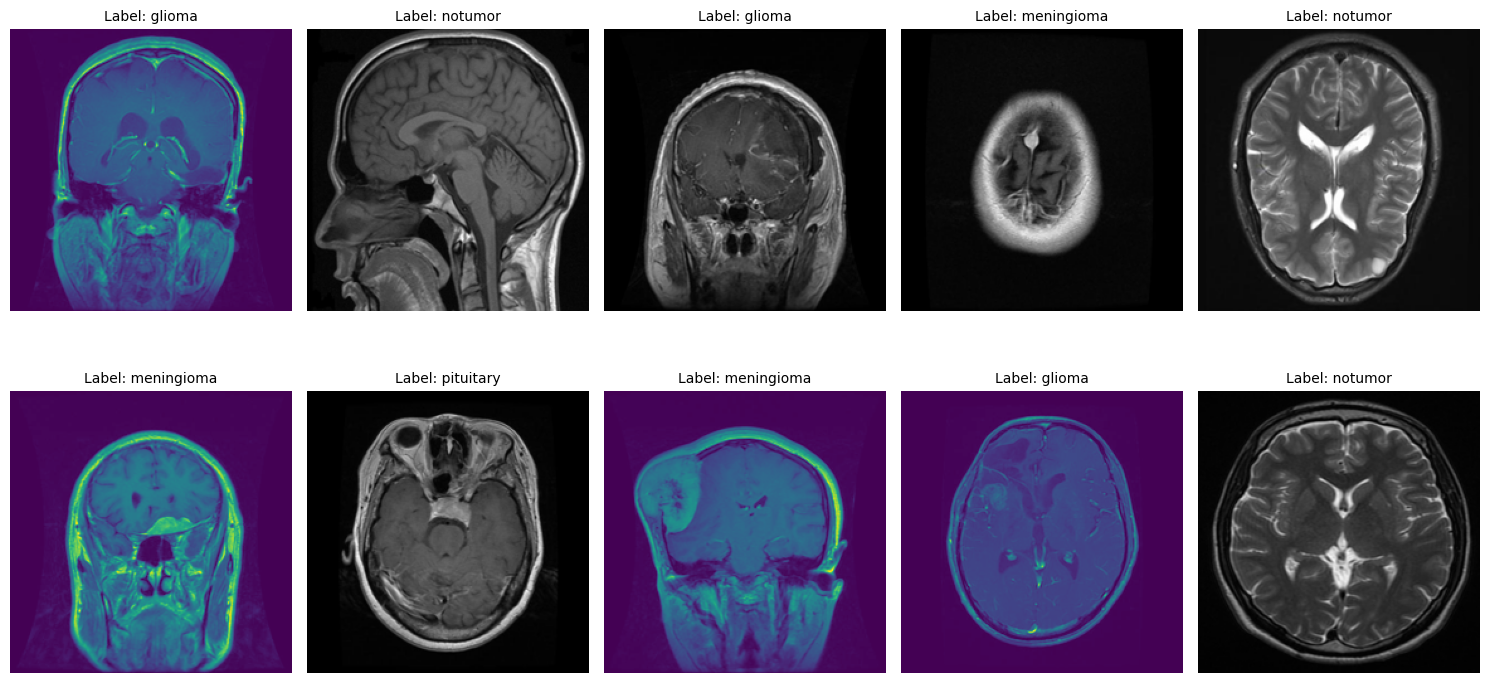

In [29]:
# Visualize some training samples
random_indices = random.sample(range(len(train_paths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(15, 8))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    img = Image.open(train_paths[idx]).resize((224, 224))
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f"Label: {train_labels[idx]}", fontsize=10)

plt.tight_layout()
plt.show()


## Image loading & augmentation

ResNet50 expects images sized **224x224** and preprocessed with its own `preprocess_input` (it applies ImageNet mean-subtraction/BGR conversion internally) — **do not** manually rescale to [0, 1] like with VGG16.

In [6]:
IMAGE_SIZE = 224  # ResNet50 default input size

# Image Augmentation
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image)
    return image

# Load images (kept in raw 0-255 range; preprocess_input handles normalization)
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = img_to_array(image)
        image = augment_image(image)
        images.append(image)
    images = np.array(images)
    return preprocess_input(images)


def encode_label(labels):
    return np.array([CLASS_LABELS.index(label) for label in labels])

# Data generator
def datagen(paths, labels, batch_size=20, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths  = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = encode_label(labels[i:i + batch_size])
            yield batch_images, batch_labels


## Build the model

**Phase 1 — Feature extraction:** freeze the entire ResNet50 backbone and train only the new classification head.

**Phase 2 — Fine-tuning:** unfreeze the top block(s) of the backbone and continue training with a much smaller learning rate, so the pretrained ImageNet features are nudged toward MRI features instead of being destroyed. ResNet50 has more layers than EfficientNetB0, so we unfreeze proportionally (last ~20 layers, roughly the final residual block).

In [7]:
# Build Model
base_model = ResNet50(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Phase 1: freeze the entire backbone
base_model.trainable = False

inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(len(CLASS_LABELS), activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,692 (91.01 MB)

 Trainable params: 266,884 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

### Phase 1 training — train the classification head only

In [8]:
# Train the Model (Phase 1: frozen backbone)
batch_size = 20
epochs_phase1 = 5
steps = int(len(train_paths) / batch_size)

history1 = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs_phase1),
    epochs=epochs_phase1,
    steps_per_epoch=steps
)


Epoch 1/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 371s 1s/step - loss: 0.5587 - sparse_categorical_accuracy: 0.8275
Epoch 2/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 378s 1s/step - loss: 0.2650 - sparse_categorical_accuracy: 0.9041
Epoch 3/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 161s 573ms/step - loss: 0.1756 - sparse_categorical_accuracy: 0.9339
Epoch 4/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 187s 668ms/step - loss: 0.1392 - sparse_categorical_accuracy: 0.9459
Epoch 5/5
280/280 ━━━━━━━━━━━━━━━━━━━━ 213s 760ms/step - loss: 0.1203 - sparse_categorical_accuracy: 0.9573


### Phase 2 training — unfreeze top layers and fine-tune

Unfreeze the last ~20 layers of ResNet50 (the final residual block, which learns the most task-specific features) and continue training with a low learning rate.

In [9]:
# Phase 2: unfreeze the top layers of the backbone for fine-tuning
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 20  # unfreeze last 20 layers (~final residual block)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNorm layers frozen even inside the unfrozen block (critical for ResNet — it relies
# heavily on BatchNorm between every conv layer, so this matters even more than for EfficientNet)
for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # much smaller LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,858,692 (91.01 MB)

 Trainable params: 9,185,924 (35.04 MB)

 Non-trainable params: 14,672,768 (55.97 MB)

In [11]:
epochs_phase2 = 10

callbacks = [
    EarlyStopping(monitor='loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='loss', factor=0.5, patience=2, min_lr=1e-7)
]

history2 = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs_phase2),
    epochs=epochs_phase2,
    steps_per_epoch=steps,
    callbacks=callbacks
)


Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 183s 653ms/step - loss: 0.0748 - sparse_categorical_accuracy: 0.9730 - learning_rate: 1.0000e-05
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 677s 2s/step - loss: 0.0499 - sparse_categorical_accuracy: 0.9839 - learning_rate: 1.0000e-05
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 202s 721ms/step - loss: 0.0350 - sparse_categorical_accuracy: 0.9895 - learning_rate: 1.0000e-05
Epoch 4/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 213s 761ms/step - loss: 0.0263 - sparse_categorical_accuracy: 0.9937 - learning_rate: 1.0000e-05
Epoch 5/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 251s 899ms/step - loss: 0.0224 - sparse_categorical_accuracy: 0.9936 - learning_rate: 1.0000e-05
Epoch 6/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 272s 972ms/step - loss: 0.0200 - sparse_categorical_accuracy: 0.9952 - learning_rate: 1.0000e-05
Epoch 7/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 272s 970ms/step - loss: 0.0187 - sparse_categorical_accuracy: 0.9950 - learning_rate: 1.0000e-05
Epoch 8/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 268s

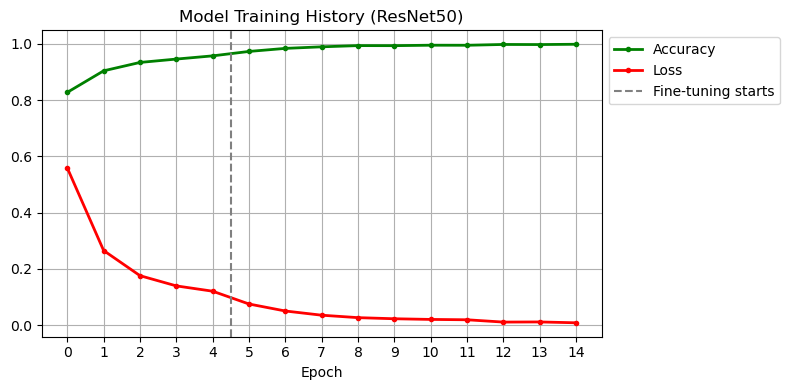

In [13]:
# Combine history from both phases for plotting
acc = history1.history['sparse_categorical_accuracy'] + history2.history['sparse_categorical_accuracy']
loss = history1.history['loss'] + history2.history['loss']
total_epochs = epochs_phase1 + len(history2.history['loss'])

plt.figure(figsize=(8, 4))
plt.grid(True)
plt.plot(acc, '.g-', linewidth=2)
plt.plot(loss, '.r-', linewidth=2)
plt.axvline(x=epochs_phase1 - 0.5, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Model Training History (ResNet50)')
plt.xlabel('Epoch')
plt.xticks(range(total_epochs))
plt.legend(['Accuracy', 'Loss', 'Fine-tuning starts'], loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


In [12]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate on test data
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

test_predictions = model.predict(test_images)
predicted_classes = np.argmax(test_predictions, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, predicted_classes, target_names=CLASS_LABELS))


50/50 ━━━━━━━━━━━━━━━━━━━━ 39s 736ms/step
Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.75      0.85       400
  meningioma       0.85      0.97      0.90       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.98      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



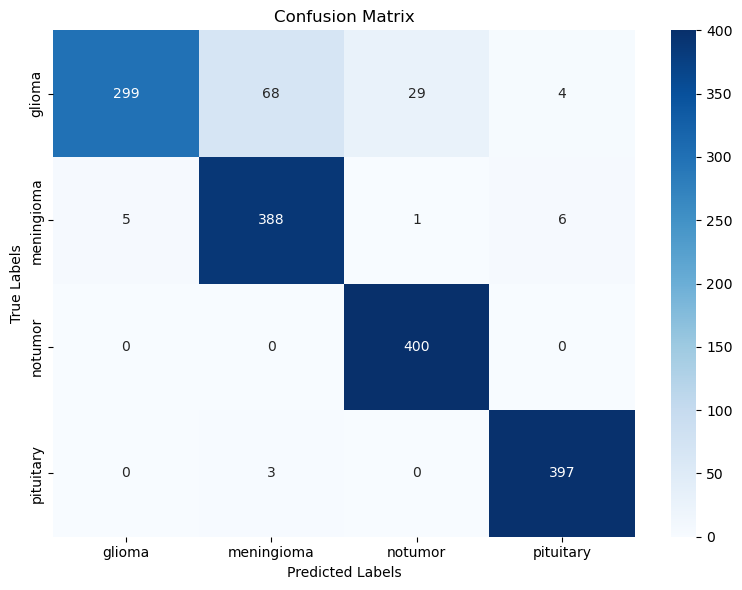

In [14]:
# Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()
plt.show()

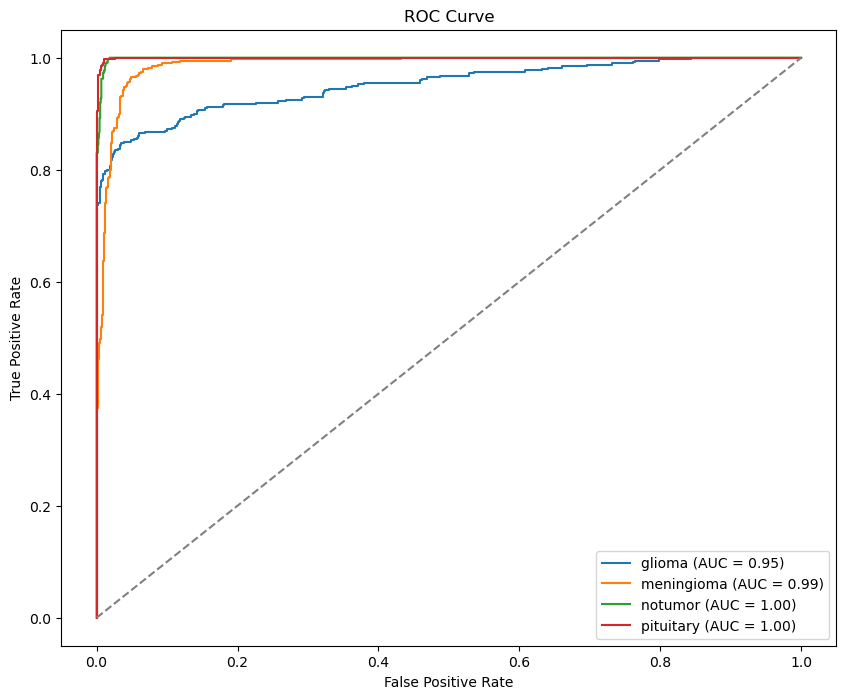

In [15]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ROC Curve
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(CLASS_LABELS)))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(CLASS_LABELS)):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(CLASS_LABELS)):
    plt.plot(fpr[i], tpr[i], label=f'{CLASS_LABELS[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


In [16]:
# Save the model
model.save('model_resnet50.h5')
print("Model saved as model_resnet50.h5")

# Also save CLASS_LABELS so you can load them later without retraining
with open('class_labels.json', 'w') as f:
    json.dump(CLASS_LABELS, f)
print("Class labels saved as class_labels.json:", CLASS_LABELS)


Model saved as model_resnet50.h5
Class labels saved as class_labels.json: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [17]:
# Load model (optional — run only if restarting kernel)
model = load_model('model_resnet50.h5')

with open('class_labels.json') as f:
    CLASS_LABELS = json.load(f)

print("Model loaded. Class labels:", CLASS_LABELS)


Model loaded. Class labels: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [19]:
# Prediction function
def detect_and_display(img_path, model, image_size=224):
    try:
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img)
        img_array = preprocess_input(img_array)
        img_array = np.expand_dims(img_array, axis=0)

        predictions = model.predict(img_array)
        predicted_index = np.argmax(predictions, axis=1)[0]
        confidence = np.max(predictions, axis=1)[0]

        predicted_label = CLASS_LABELS[predicted_index]

        if predicted_label == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {predicted_label}"

        # Show all class probabilities
        print("Probabilities:")
        for i, label in enumerate(CLASS_LABELS):
            print(f"  {label}: {predictions[0][i]*100:.2f}%")

        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 567ms/step
Probabilities:
  glioma: 0.00%
  meningioma: 100.00%
  notumor: 0.00%
  pituitary: 0.00%


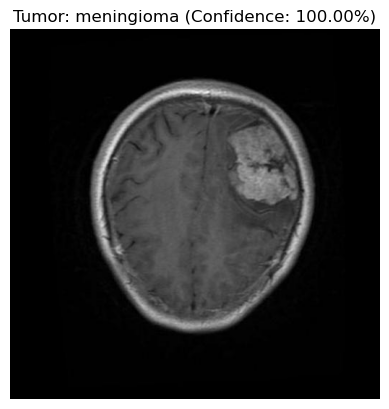

In [ ]:
# Test prediction — Pituitary Tumor
image_path = r'Dataset\Testing\meningioma\Te-aug-me_2.jpg'
detect_and_display(image_path, model)


In [ ]:
# Test prediction — Meningioma Tumor
image_path = r'Dataset\Testing\glioma\Te-gl_399.jpg' 
detect_and_display(image_path, model)


NameError: name 'detect_and_display' is not defined

In [22]:
# Test prediction — Pituitary Tumor
image_path = 'Dataset\Testing\notumor\Te-no_391.jpg'
detect_and_display(image_path, model)


Error processing the image: [Errno 22] Invalid argument: 'Dataset\\Testing\notumor\\Te-no_391.jpg'
